In [47]:
import os
import numpy as np
import pandas as pd
from Demos.SystemParametersInfo import orig_italic
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassPrecision,
    MulticlassRecall,
)
import math
from math import exp
import torchvision
from tqdm import tqdm
from underthesea.pipeline.tts.viettts_.nat.duration_trainer import optimizer

In [48]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Data prep

In [49]:
def get_img_paths(path):
    img = []
    for dirname, _, filenames in os.walk(path):
        for filename in filenames:
            img.append(os.path.join(dirname, filename))
    return img

train_img = get_img_paths("data/cifar10/train")
test_img = get_img_paths("data/cifar10/test")


In [50]:
valid_count = int(len(test_img) / 2)
valid_img = random.sample(train_img, valid_count)
valid_img_set = set(valid_img)
train_img = [
    filename for filename in train_img
    if filename not in valid_img_set
]

In [51]:
total_samples = len(train_img) + len(valid_img) + len(test_img)
print(f"Number of train samples: {len(train_img)} / {total_samples} ({(len(train_img) / total_samples * 100):.2f}%)")
print(f"Number of validation samples: {len(valid_img)} / {total_samples} ({(len(valid_img) / total_samples * 100):.2f}%)")
print(f"Number of test samples: {len(test_img)} / {total_samples} ({(len(test_img) / total_samples* 100):.2f}%)")

Number of train samples: 45000 / 60000 (75.00%)
Number of validation samples: 5000 / 60000 (8.33%)
Number of test samples: 10000 / 60000 (16.67%)


In [52]:
import csv

train_labels = pd.read_csv('data/cifar10/train_labels.csv').to_dict(orient='records')

test_labels = pd.read_csv('data/cifar10/test_labels.csv').to_dict(orient='records')

In [53]:
all_labels = sorted(list(set(row['label'] for row in train_labels)))

print(f"Total classes found: {len(all_labels)}")
print("List of labels:", all_labels)

label_to_idx = {label_name: idx for idx, label_name in enumerate(all_labels)}

Total classes found: 10
List of labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [64]:
def image_transforms(train):
    if train:
        return (transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ToTensor()
        ]))
    else:
        return transforms.ToTensor()

In [65]:
class ImageDataset(Dataset):

    def __init__(self, images, labels, label_to_idx, train=True):
        """
        Args:
            images (list): List of image paths or records.
            labels (list): List of corresponding labels.
            train (bool): True if applying training transforms, False otherwise.
        """
        super(ImageDataset, self).__init__()

        self.images = images
        self.labels = labels
        self.label_to_idx = label_to_idx
        self.train = train

        self.number_images = len(self.images)
        self.image_transforms = image_transforms(self.train)

    def __getitem__(self, index):
        actual_index = index % self.number_images

        image = Image.open(self.images[actual_index]).convert('RGB')
        str_label = self.labels[actual_index]['label']
        label_idx = self.label_to_idx[str_label]

        image = self.image_transforms(image)

        return image, label_idx

    def __len__(self):
        return self.number_images

train_dataset = ImageDataset(train_img, train_labels, label_to_idx, True)
valid_dataset = ImageDataset(valid_img, train_labels, label_to_idx, False)
test_dataset = ImageDataset(test_img, test_labels, label_to_idx, False)

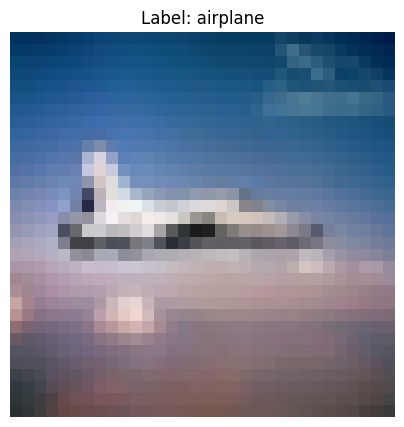

In [66]:
image_tensor, label = train_dataset[random.randint(0, len(train_dataset))]

if isinstance(image_tensor, torch.Tensor):
    image_to_show = image_tensor.permute(1, 2, 0).numpy()

    import numpy as np
    image_to_show = np.clip(image_to_show, 0, 1)
else:
    image_to_show = image_tensor

plt.figure(figsize=(5, 5))
plt.imshow(image_to_show)
plt.title(f"Label: {all_labels[label]}")
plt.axis('off')
plt.show()

In [67]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Models

In [68]:
# Basic LeNet test
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5), # 28x28x6
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2), #14x14x6
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5), # 10x10x6
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2), #5x5x6
            nn.Flatten()
        )
        self.dense = nn.Sequential(
        nn.Linear(16 * 5 * 5, 120),
        nn.Sigmoid(),
        nn.Linear(120, 84),
        nn.Sigmoid(),
        nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.dense(x)
        return x


In [69]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device {DEVICE}')
NUM_WORKERS = os.cpu_count()
print(f'Total available CPUs: {NUM_WORKERS}')

Using device cpu
Total available CPUs: 16


In [70]:
model = LeNet().to(DEVICE)

In [71]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=1e-4, weight_decay=0.0001),
])
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=5e-5,
)

In [75]:
def epoch_train(model, dataloader, criterion, optimizer, device, num_classes):
    model.train()

    f1_metric = MulticlassF1Score(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    accuracy_metric = MulticlassAccuracy(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    precision_metric = MulticlassPrecision(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    recall_metric = MulticlassRecall(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    total_loss = 0.0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc="Training")

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = model(images)
        batch_loss = criterion(outputs, labels)

        batch_loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += batch_loss.item() * batch_size
        total_samples += batch_size

        # TorchMetrics accepts multiclass logits directly.
        f1_metric.update(outputs, labels)
        accuracy_metric.update(outputs, labels)
        precision_metric.update(outputs, labels)
        recall_metric.update(outputs, labels)

        progress_bar.set_postfix(loss=batch_loss.item())

    return {
        "loss": total_loss / total_samples,
        "f1": f1_metric.compute().item(),
        "accuracy": accuracy_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
    }


@torch.no_grad()
def epoch_validate(model, dataloader, criterion, device, num_classes):
    model.eval()

    f1_metric = MulticlassF1Score(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    accuracy_metric = MulticlassAccuracy(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    precision_metric = MulticlassPrecision(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    recall_metric = MulticlassRecall(
        num_classes=num_classes,
        average="macro",
    ).to(device)

    total_loss = 0.0
    total_samples = 0

    for images, labels in tqdm(dataloader, desc="Validation"):
        images = images.to(device)
        labels = labels.to(device).long()

        outputs = model(images)
        batch_loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        total_loss += batch_loss.item() * batch_size
        total_samples += batch_size

        f1_metric.update(outputs, labels)
        accuracy_metric.update(outputs, labels)
        precision_metric.update(outputs, labels)
        recall_metric.update(outputs, labels)

    return {
        "loss": total_loss / total_samples,
        "f1": f1_metric.compute().item(),
        "accuracy": accuracy_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
    }

In [76]:
EPOCHS = 10
train_logs = []
valid_logs = []

for i in range(EPOCHS):
    print(f"Epoch {i+1} / {EPOCHS}")
    train_result = epoch_train(
        model=model,
        dataloader=train_loader,
        criterion=loss,
        optimizer=optimizer,
        device=DEVICE,
        num_classes=10
    )
    print(train_result)
    valid_result = epoch_validate(
        model=model,
        dataloader=valid_loader,
        criterion=loss,
        device=DEVICE,
        num_classes=10
    )
    print(valid_result)
    train_logs.append(train_result)
    valid_logs.append(valid_result)


print("Train:", train_logs)
print("Valid:", valid_logs)

Epoch 1 / 10


Training: 100%|██████████| 2813/2813 [02:30<00:00, 18.64it/s, loss=2.19]


{'loss': 2.193157584847344, 'f1': 0.12542423605918884, 'accuracy': 0.1313333362340927, 'precision': 0.12747842073440552, 'recall': 0.1313333362340927}


Validation: 100%|██████████| 313/313 [00:06<00:00, 50.67it/s]


{'loss': 2.2524972660064697, 'f1': 0.014988596551120281, 'accuracy': 0.007666666526347399, 'precision': 0.3333333432674408, 'recall': 0.007666666526347399}
Epoch 2 / 10


...

{'loss': 2.0336171343485514, 'f1': 0.17120321094989777, 'accuracy': 0.1989777833223343, 'precision': 0.17807482182979584, 'recall': 0.1989777833223343}


Validation: 100%|██████████| 313/313 [00:03<00:00, 96.04it/s]


{'loss': 2.5864414150238035, 'f1': 0.04876430705189705, 'accuracy': 0.029400000348687172, 'precision': 0.1428571492433548, 'recall': 0.029400000348687172}
Epoch 7 / 10


Training:  99%|█████████▉| 2784/2813 [01:56<00:01, 23.87it/s, loss=1.79]


KeyboardInterrupt: 